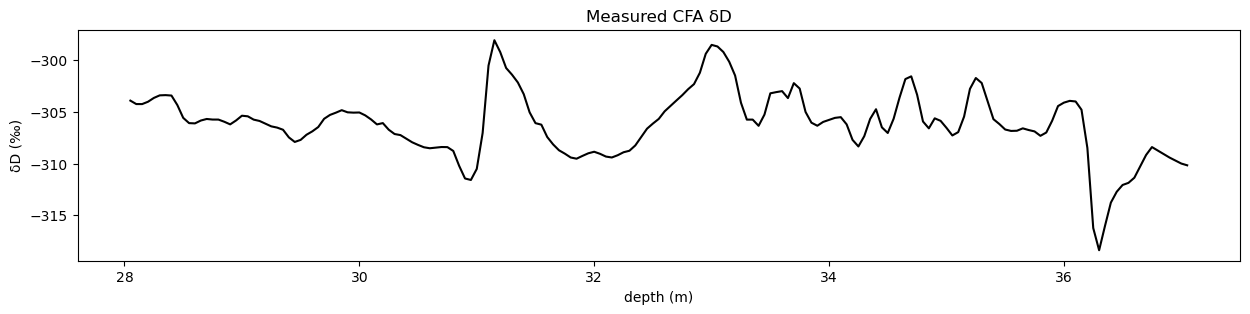

181 samples from 28.05 to 37.05 m


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('~/Downloads/ALHIC2302_CFA_(water-isotopes-CH4-dust).csv')
df = df.rename(columns={'depth (m)': 'depth', 'dD (per mille)': 'dD'})
df = df.groupby('depth', as_index=False).mean(numeric_only=True)   # average duplicate depths

START, END = 28.0, 37.1          # an unbroken stretch of ALHIC2302 (no gaps in dD here)
piece = df[(df.depth >= START) & (df.depth <= END)].dropna(subset=['dD'])

DZ = 0.05                        # 5 cm between samples
z = np.round(np.arange(piece.depth.min(), piece.depth.max() + DZ / 2, DZ), 2)
y = np.interp(z, piece.depth, piece['dD'])     # put on an exact 5 cm grid
n = len(y)

plt.figure(figsize=(15, 3))
plt.plot(z, y, 'k')
plt.xlabel('depth (m)'); plt.ylabel('δD (‰)'); plt.title('Measured CFA δD')
plt.show()
print(n, 'samples from', z[0], 'to', z[-1], 'm')


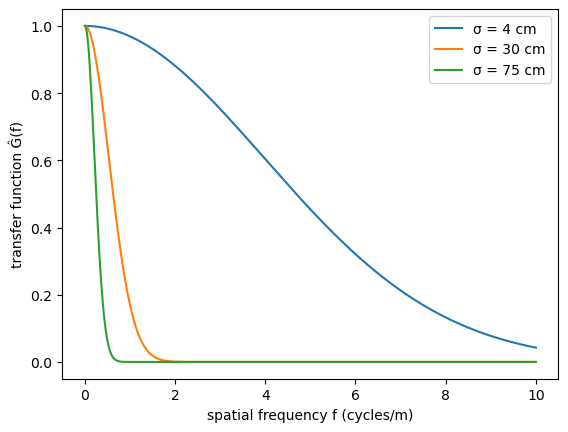

In [26]:
def transfer_function(f, sigma_cm):
    sigma = sigma_cm / 100                          # cm -> m
    return np.exp(-2 * np.pi**2 * sigma**2 * f**2)

f_demo = np.linspace(0, 10, 500)                    # 0 to Nyquist (10 cycles/m for 5 cm sampling)
for sigma_cm in [4, 30, 75]:
    plt.plot(f_demo, transfer_function(f_demo, sigma_cm), label=f'σ = {sigma_cm} cm')
plt.xlabel('spatial frequency f (cycles/m)')
plt.ylabel('transfer function Ĝ(f)')
plt.legend(); plt.show()


In [27]:
mean = y.mean()
y_mirrored = np.concatenate([(y - mean)[::-1], y - mean, (y - mean)[::-1]])

Y = np.fft.rfft(y_mirrored)                       # Fourier transform of the record
f = np.fft.rfftfreq(len(y_mirrored), DZ)          # spatial frequencies (cycles/m), 0 to Nyquist (10)

def back_to_depth(spectrum):
    # inverse Fourier transform, keeping only the real (middle) stretch
    return np.fft.irfft(spectrum, n=len(y_mirrored))[n:2 * n] + mean

print('largest difference after a round trip:', np.abs(back_to_depth(Y) - y).max())


largest difference after a round trip: 0.0


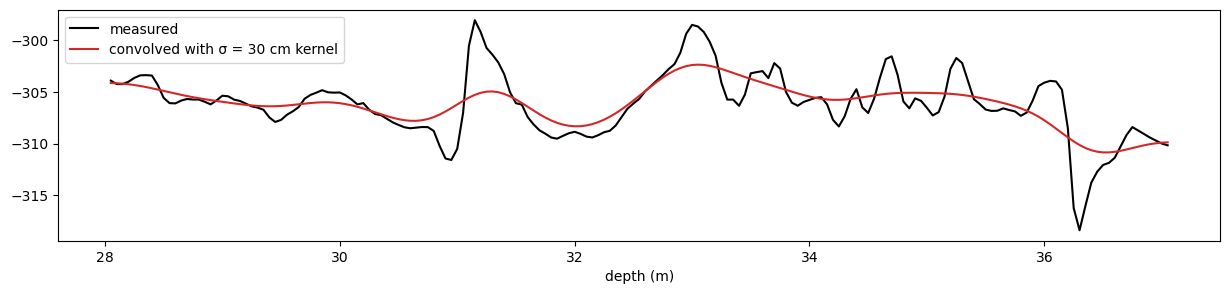

In [28]:
blurred_30 = back_to_depth(transfer_function(f, 30) * Y)

plt.figure(figsize=(15, 3))
plt.plot(z, y, 'k', label='measured')
plt.plot(z, blurred_30, 'C3', label='convolved with σ = 30 cm kernel')
plt.legend(); plt.xlabel('depth (m)'); plt.show()


In [29]:
for sigma_cm in [4, 30]:
    print(f'σ = {sigma_cm} cm: largest gain needed (1 / Ĝ at Nyquist) = {1 / transfer_function(f, sigma_cm).min():.3g} times')


σ = 4 cm: largest gain needed (1 / Ĝ at Nyquist) = 23.3 times
σ = 30 cm: largest gain needed (1 / Ĝ at Nyquist) = 7.41e+76 times


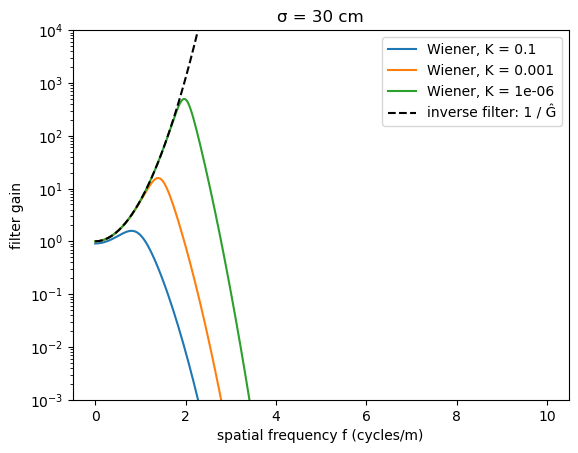

In [30]:
def wiener(f, sigma_cm, K):
    G = transfer_function(f, sigma_cm)
    return G / (G**2 + K)

for K in [1e-1, 1e-3, 1e-6]:
    plt.semilogy(f, wiener(f, 30, K), label=f'Wiener, K = {K:g}')
plt.semilogy(f, 1 / transfer_function(f, 30), 'k--', label='inverse filter: 1 / Ĝ')
plt.ylim(1e-3, 1e4)
plt.xlabel('spatial frequency f (cycles/m)'); plt.ylabel('filter gain')
plt.title('σ = 30 cm'); plt.legend(); plt.show()


In [31]:
d = np.diff(y)
NOISE = 1.4826 * np.median(np.abs(d - np.median(d))) / np.sqrt(2)
print(f'noise estimate: {NOISE:.2f} ‰')


noise estimate: 0.46 ‰


In [32]:
def deconvolve_and_check(sigma_cm, K):
    W = wiener(f, sigma_cm, K)
    deconvolved = back_to_depth(W * Y)                                        # Wiener estimate of the original
    reblurred = back_to_depth(transfer_function(f, sigma_cm) * W * Y)         # forward model applied to it
    residual_rms = np.sqrt(np.mean((reblurred - y) ** 2))                     # misfit to the measurements
    return deconvolved, reblurred, residual_rms

rows = []
for sigma_cm in [4, 30]:
    for K in 10.0 ** np.arange(0, -13, -1):                          # K = 1, 0.1, ..., 1e-12
        deconvolved, reblurred, residual_rms = deconvolve_and_check(sigma_cm, K)
        rows.append({'σ (cm)': sigma_cm, 'K': f'{K:g}', 'residual RMS / noise': residual_rms / NOISE,
                     'deconvolved range (‰)': np.ptp(deconvolved)})
table = pd.DataFrame(rows)
print(table.round(2).to_string())


    σ (cm)       K  residual RMS / noise  deconvolved range (‰)
0        4       1                  3.60                   9.97
1        4     0.1                  0.75                  21.05
2        4    0.01                  0.13                  23.13
3        4   0.001                  0.03                  24.18
4        4  0.0001                  0.00                  24.98
5        4   1e-05                  0.00                  25.08
6        4   1e-06                  0.00                  25.09
7        4   1e-07                  0.00                  25.09
8        4   1e-08                  0.00                  25.09
9        4   1e-09                  0.00                  25.09
10       4   1e-10                  0.00                  25.09
11       4   1e-11                  0.00                  25.09
12       4   1e-12                  0.00                  25.09
13      30       1                  5.48                   5.19
14      30     0.1                  4.16

In [33]:
def best_K(sigma_cm):
    for K in 10.0 ** np.arange(0, -13, -1):              # from tame to wild
        if deconvolve_and_check(sigma_cm, K)[2] <= NOISE:
            return K
    return None                                          # no K gets within noise

for sigma_cm in [4, 30]:
    K = best_K(sigma_cm)
    print(f'σ = {sigma_cm} cm: ', 'no K fits within noise' if K is None else f'K = {K:g} fits within noise')


σ = 4 cm:  K = 0.1 fits within noise
σ = 30 cm:  no K fits within noise


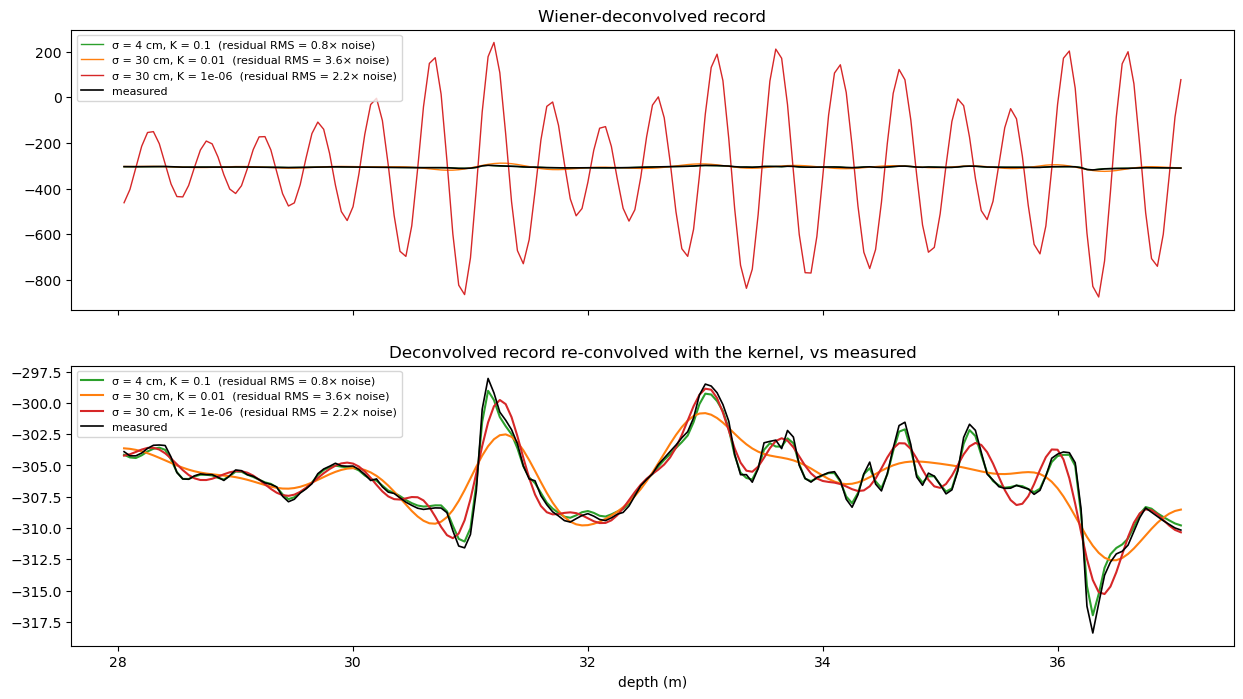

In [34]:
fig, ax = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
cases = [(4, best_K(4), 'C2'), (30, 1e-2, 'C1'), (30, 1e-6, 'C3')]
for sigma_cm, K, color in cases:
    deconvolved, reblurred, residual_rms = deconvolve_and_check(sigma_cm, K)
    label = f'σ = {sigma_cm} cm, K = {K:g}  (residual RMS = {residual_rms / NOISE:.1f}× noise)'
    ax[0].plot(z, deconvolved, color, lw=1, label=label)
    ax[1].plot(z, reblurred, color, lw=1.5, label=label)
for a in ax:
    a.plot(z, y, 'k', lw=1.2, label='measured')
    a.legend(fontsize=8)
ax[0].set_title('Wiener-deconvolved record')
ax[1].set_title('Deconvolved record re-convolved with the kernel, vs measured')
ax[1].set_xlabel('depth (m)')
plt.show()


In [35]:
from scipy.special import erf

SIGMAS_CM = [2, 5, 10, 15, 20, 30, 50, 75, 100]
H = 0.05                                        # sample spacing (m)

rows = []
for name, df in cores.items():
    for var in ['d18O', 'dD', 'CH4']:
        s = df.set_index('depth')[var].dropna()
        neighbours = np.isclose(np.diff(s.index), H)                    # true 5 cm neighbours only
        biggest_jump = np.abs(np.diff(s.values))[neighbours].max()
        row = {'core': name, 'proxy': var,
               'measured range': np.ptp(s.values), 'biggest 5 cm jump': biggest_jump}
        for sigma_cm in SIGMAS_CM:
            # minimum range of the original needed to produce that jump after a sigma blur
            row[f'σ={sigma_cm}'] = biggest_jump / erf(H / (2 * np.sqrt(2) * sigma_cm / 100))
        rows.append(row)
required_range = pd.DataFrame(rows).round(1)
required_range


,core,proxy,measured range,biggest 5 cm jump,σ=2,σ=5,σ=10,σ=15,σ=20,σ=30,σ=50,σ=75,σ=100
0,ALHIC2201,d18O,8.7,3.1,3.9,8.1,15.8,23.5,31.3,46.9,78.1,117.2,156.2
1,ALHIC2201,dD,64.7,23.0,29.2,60.1,116.6,173.9,231.4,346.6,577.3,865.8,1154.3
2,ALHIC2201,CH4,455.0,230.8,292.7,602.8,1169.3,1743.9,2320.5,3475.8,5788.7,8681.0,11573.7
3,ALHIC2302,d18O,4.4,1.4,1.7,3.6,6.9,10.3,13.8,20.6,34.3,51.5,68.7
4,ALHIC2302,dD,37.9,13.8,17.5,36.0,69.8,104.0,138.5,207.4,345.4,517.9,690.5
5,ALHIC2302,CH4,463.7,121.9,154.5,318.2,617.2,920.5,1224.9,1834.7,3055.6,4582.4,6109.3


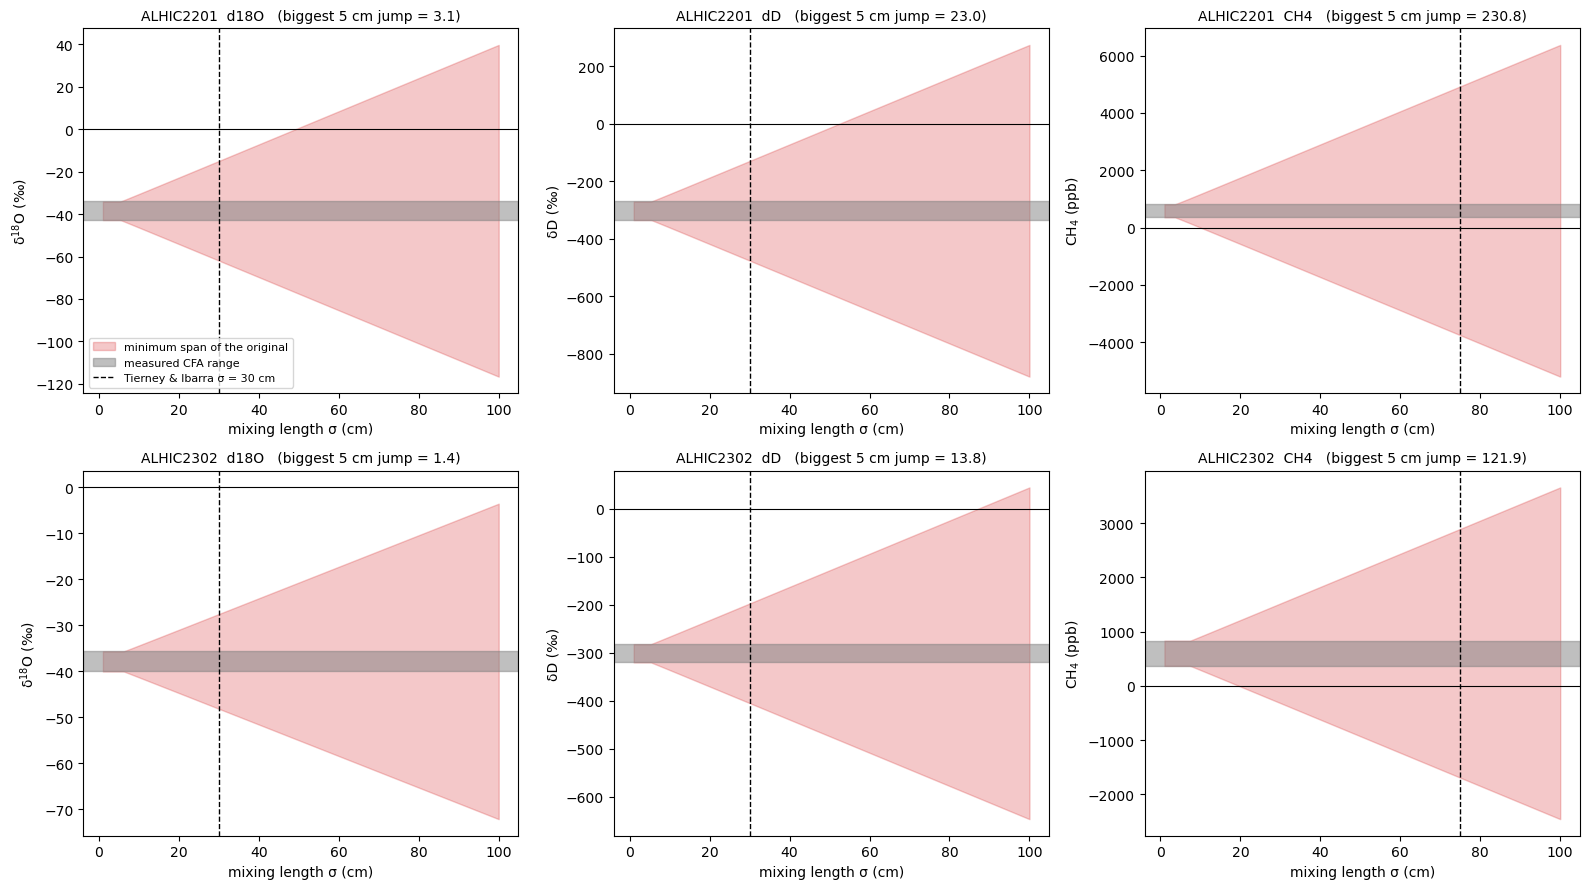

In [36]:
from scipy.special import erf

H = 0.05                                          # sample spacing (m)
sigma_cm = np.linspace(1, 100, 300)               # mixing lengths to plot
TIERNEY = {'d18O': 30, 'dD': 30, 'CH4': 75}
LABELS = {'d18O': 'δ$^{18}$O (‰)', 'dD': 'δD (‰)', 'CH4': 'CH$_4$ (ppb)'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, (name, df) in enumerate(cores.items()):
    for j, var in enumerate(['d18O', 'dD', 'CH4']):
        ax = axes[i, j]
        s = df.set_index('depth')[var].dropna()
        neighbours = np.isclose(np.diff(s.index), H)
        biggest_jump = np.abs(np.diff(s.values))[neighbours].max()
        lo, hi = s.min(), s.max()
        mid = (lo + hi) / 2

        # minimum range the original needs, for each sigma
        R = biggest_jump / erf(H / (2 * np.sqrt(2) * sigma_cm / 100))
        R = np.maximum(R, hi - lo)                # can never be smaller than what was measured

        ax.fill_between(sigma_cm, mid - R / 2, mid + R / 2, color='C3', alpha=0.25,
                        label='minimum span of the original')
        ax.axhspan(lo, hi, color='0.5', alpha=0.5, label='measured CFA range')
        ax.axvline(TIERNEY[var], color='k', ls='--', lw=1,
                   label=f'Tierney & Ibarra σ = {TIERNEY[var]} cm')
        ax.axhline(0, color='k', lw=0.8)          # CH4 cannot be negative; δ = 0 is seawater
        ax.set_title(f'{name}  {var}   (biggest 5 cm jump = {biggest_jump:.1f})', fontsize=10)
        ax.set_xlabel('mixing length σ (cm)'); ax.set_ylabel(LABELS[var])
axes[0, 0].legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()


ALHIC2201 d18O: jump 2.52, span at σ=30: 38.0 (-57.4 to -19.5); measured -42.8 to -34.1
ALHIC2201 dD: jump 20.46, span at σ=30: 308.1 (-456.4 to -148.3); measured -334.7 to -270.0
ALHIC2201 CH4: jump 181.33, span at σ=75: 6819.1 (-2824.9 to 3994.3); measured 357.2 to 812.2
ALHIC2302 d18O: jump 1.05, span at σ=30: 15.8 (-45.8 to -30.0); measured -40.1 to -35.7
ALHIC2302 dD: jump 10.84, span at σ=30: 163.2 (-382.5 to -219.3); measured -319.8 to -281.9
ALHIC2302 CH4: jump 89.64, span at σ=75: 3371.2 (-1084.8 to 2286.3); measured 368.9 to 832.6


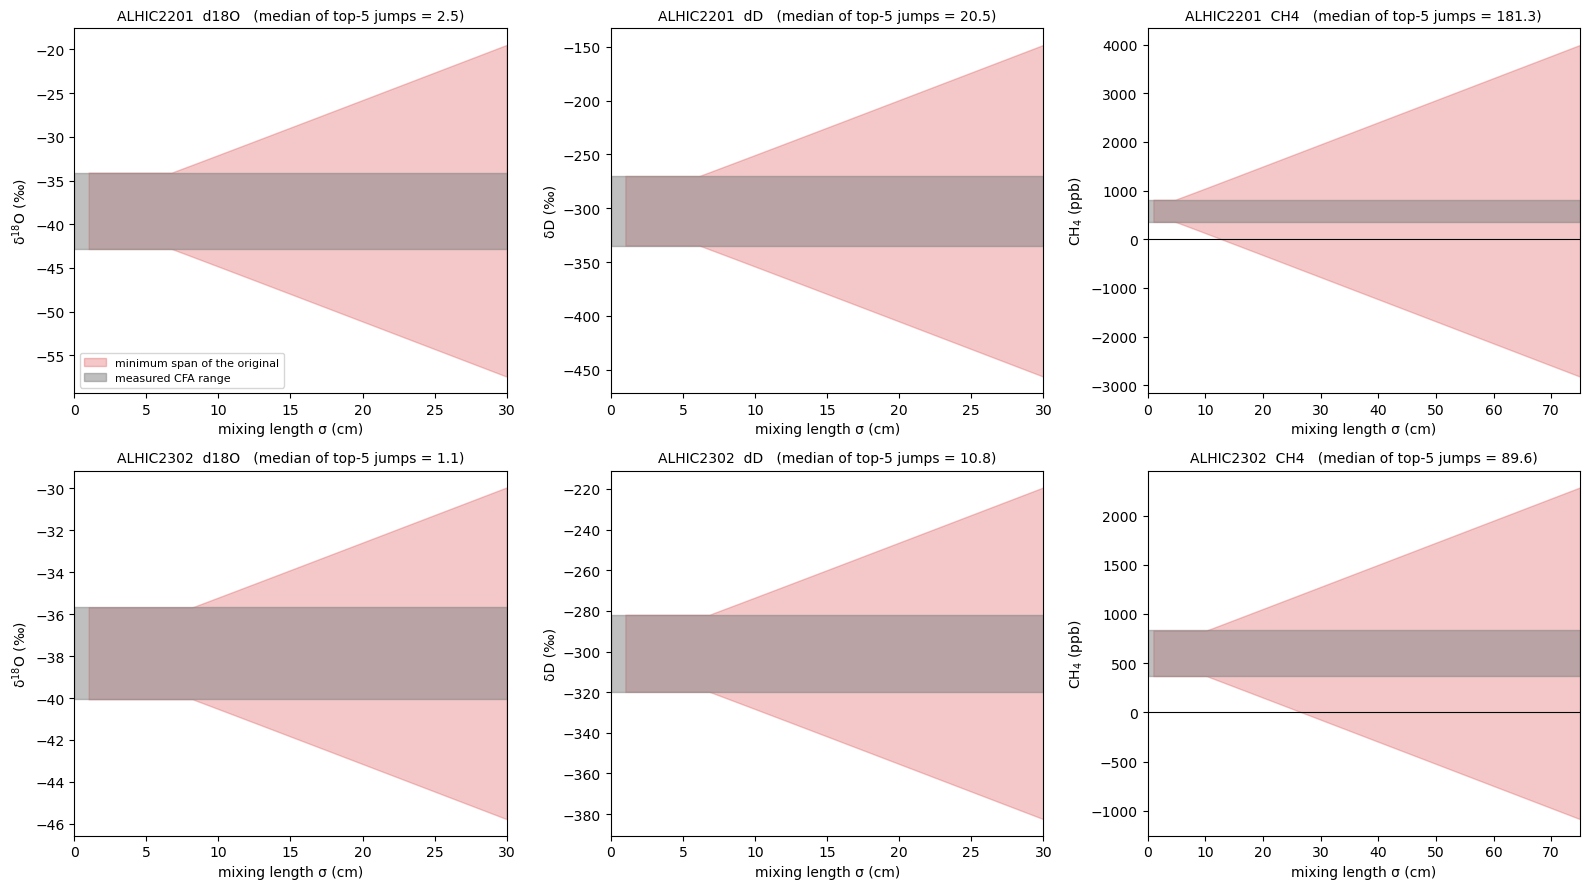

In [37]:
from scipy.special import erf

H = 0.05                                          # sample spacing (m)
TIERNEY = {'d18O': 30, 'dD': 30, 'CH4': 75}       # mixing lengths (cm); x-axis ends here
LABELS = {'d18O': 'δ$^{18}$O (‰)', 'dD': 'δD (‰)', 'CH4': 'CH$_4$ (ppb)'}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for i, (name, df) in enumerate(cores.items()):
    for j, var in enumerate(['d18O', 'dD', 'CH4']):
        ax = axes[i, j]
        s = df.set_index('depth')[var].dropna()
        neighbours = np.isclose(np.diff(s.index), H)
        jumps = np.abs(np.diff(s.values))[neighbours]
        jump = np.median(np.sort(jumps)[-5:])            # median of the 5 largest 5 cm jumps
        lo, hi = s.min(), s.max()
        mid = (lo + hi) / 2

        sigma_cm = np.linspace(1, TIERNEY[var], 300)
        R = jump / erf(H / (2 * np.sqrt(2) * sigma_cm / 100))   # minimum range of the original
        R = np.maximum(R, hi - lo)                        # never smaller than what was measured

        ax.fill_between(sigma_cm, mid - R / 2, mid + R / 2, color='C3', alpha=0.25,
                        label='minimum span of the original')
        ax.axhspan(lo, hi, color='0.5', alpha=0.5, label='measured CFA range')
        if var == 'CH4':
            ax.axhline(0, color='k', lw=0.8)              # CH4 cannot be negative
        ax.set_xlim(0, TIERNEY[var])
        ax.set_title(f'{name}  {var}   (median of top-5 jumps = {jump:.1f})', fontsize=10)
        ax.set_xlabel('mixing length σ (cm)'); ax.set_ylabel(LABELS[var])
        print(f'{name} {var}: jump {jump:.2f}, span at σ={TIERNEY[var]}: {R[-1]:.1f} '
              f'({mid - R[-1]/2:.1f} to {mid + R[-1]/2:.1f}); measured {lo:.1f} to {hi:.1f}')
axes[0, 0].legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()


In [38]:
from scipy.special import erf

H = 0.05
TIERNEY = {'d18O': 30, 'dD': 30, 'CH4': 75}
LABELS = {'d18O': 'δ$^{18}$O (‰)', 'dD': 'δD (‰)', 'CH4': 'CH$_4$ (ppb)'}
N_DRAWS = 200
rng = np.random.default_rng(0)

def mc_originals(df, var, sigma_cm):
    s = df.set_index('depth')[var].dropna()
    z_all, y_all = s.index.values, s.values

    # The bound: minimum span R the original needs (median of the top-5 jumps)
    neighbours = np.isclose(np.diff(z_all), H)
    jump = np.median(np.sort(np.abs(np.diff(y_all))[neighbours])[-5:])
    R = max(jump / erf(H / (2 * np.sqrt(2) * sigma_cm / 100)), np.ptp(y_all))
    mid = (y_all.min() + y_all.max()) / 2
    tau = R / 4                                   # prior: original ~ mid ± 2 tau, i.e. spans ~R

    # Measurement noise (rough overestimate from 5 cm differences)
    d = np.diff(y_all)
    noise = 1.4826 * np.median(np.abs(d - np.median(d))) / np.sqrt(2)

    draws = np.full((len(z_all), N_DRAWS), np.nan)
    reblurred = np.full((len(z_all), N_DRAWS), np.nan)
    pieces = np.split(np.arange(len(z_all)), np.where(np.diff(z_all) > 0.15)[0] + 1)
    for idx in pieces:                            # each unbroken stretch separately
        z, y = z_all[idx], y_all[idx]
        G = np.exp(-0.5 * ((z[:, None] - z[None, :]) / (sigma_cm / 100)) ** 2)
        G /= G.sum(axis=1, keepdims=True)         # Tierney's blur as a matrix
        # Gaussian posterior for the original, given the data, noise and prior spread
        A = G.T @ G / noise**2 + np.eye(len(z)) / tau**2
        centre = mid + np.linalg.solve(A, G.T @ (y - mid) / noise**2)
        L = np.linalg.cholesky(A)
        x = centre[:, None] + np.linalg.solve(L.T, rng.standard_normal((len(z), N_DRAWS)))
        draws[idx] = x
        reblurred[idx] = G @ x                    # each draw, blurred again
    return z_all, y_all, draws, reblurred, R, noise


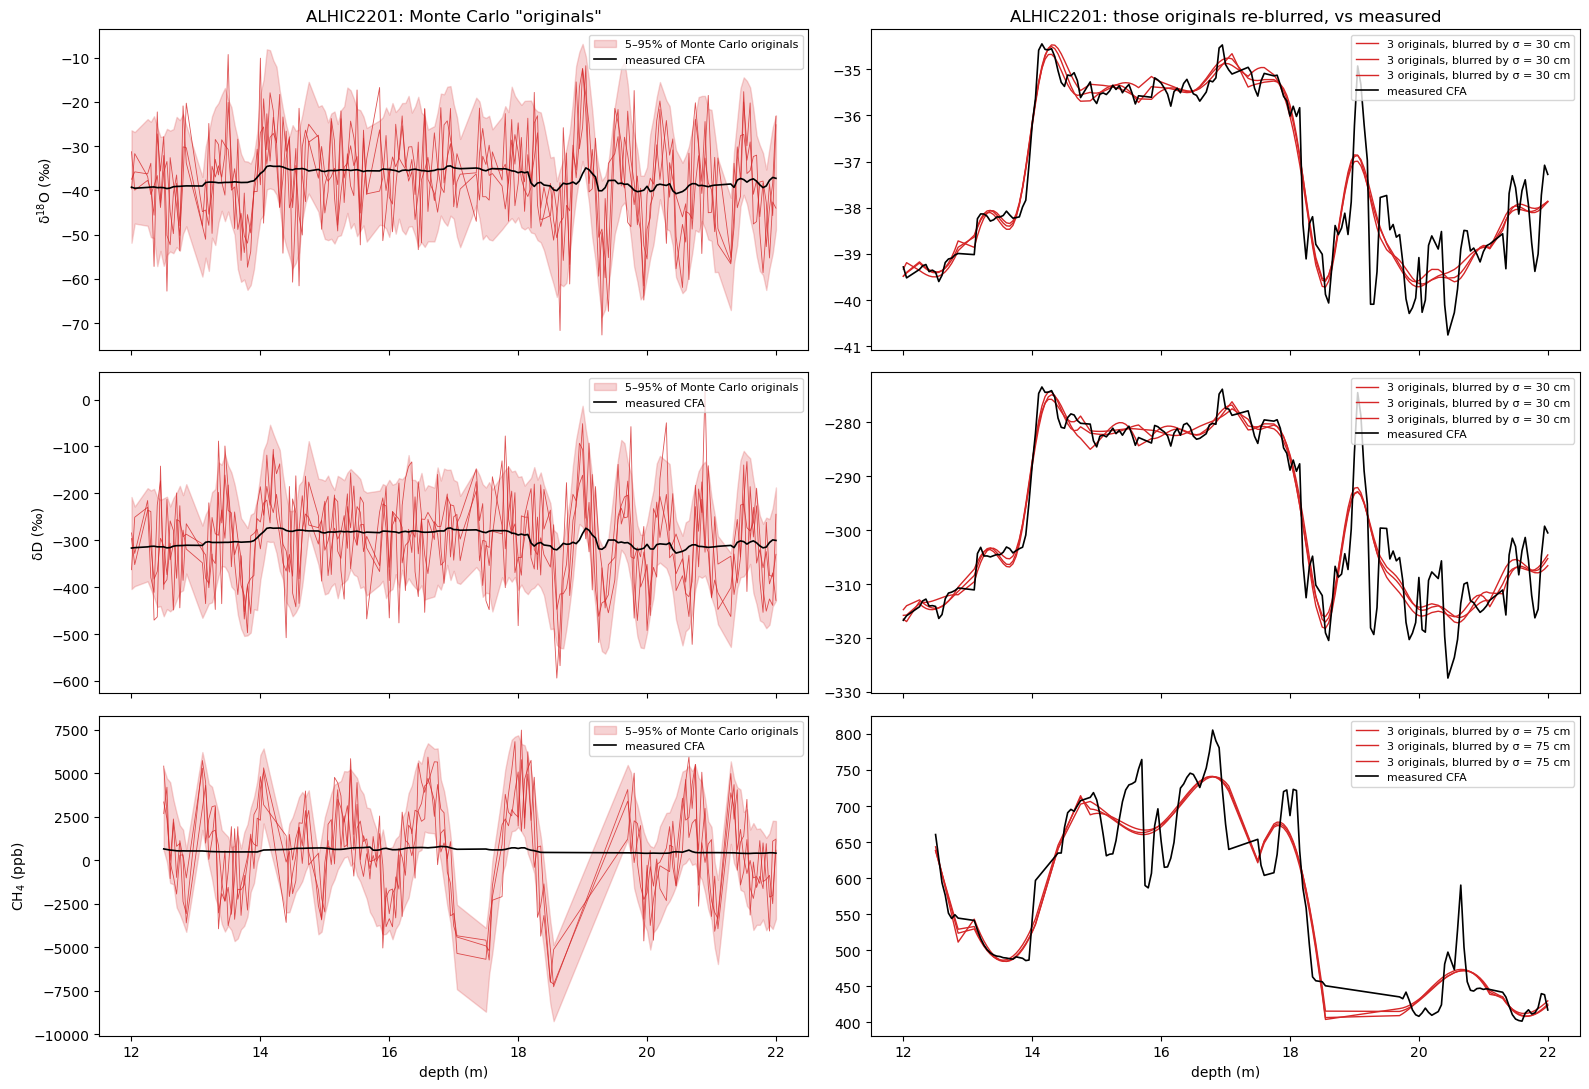

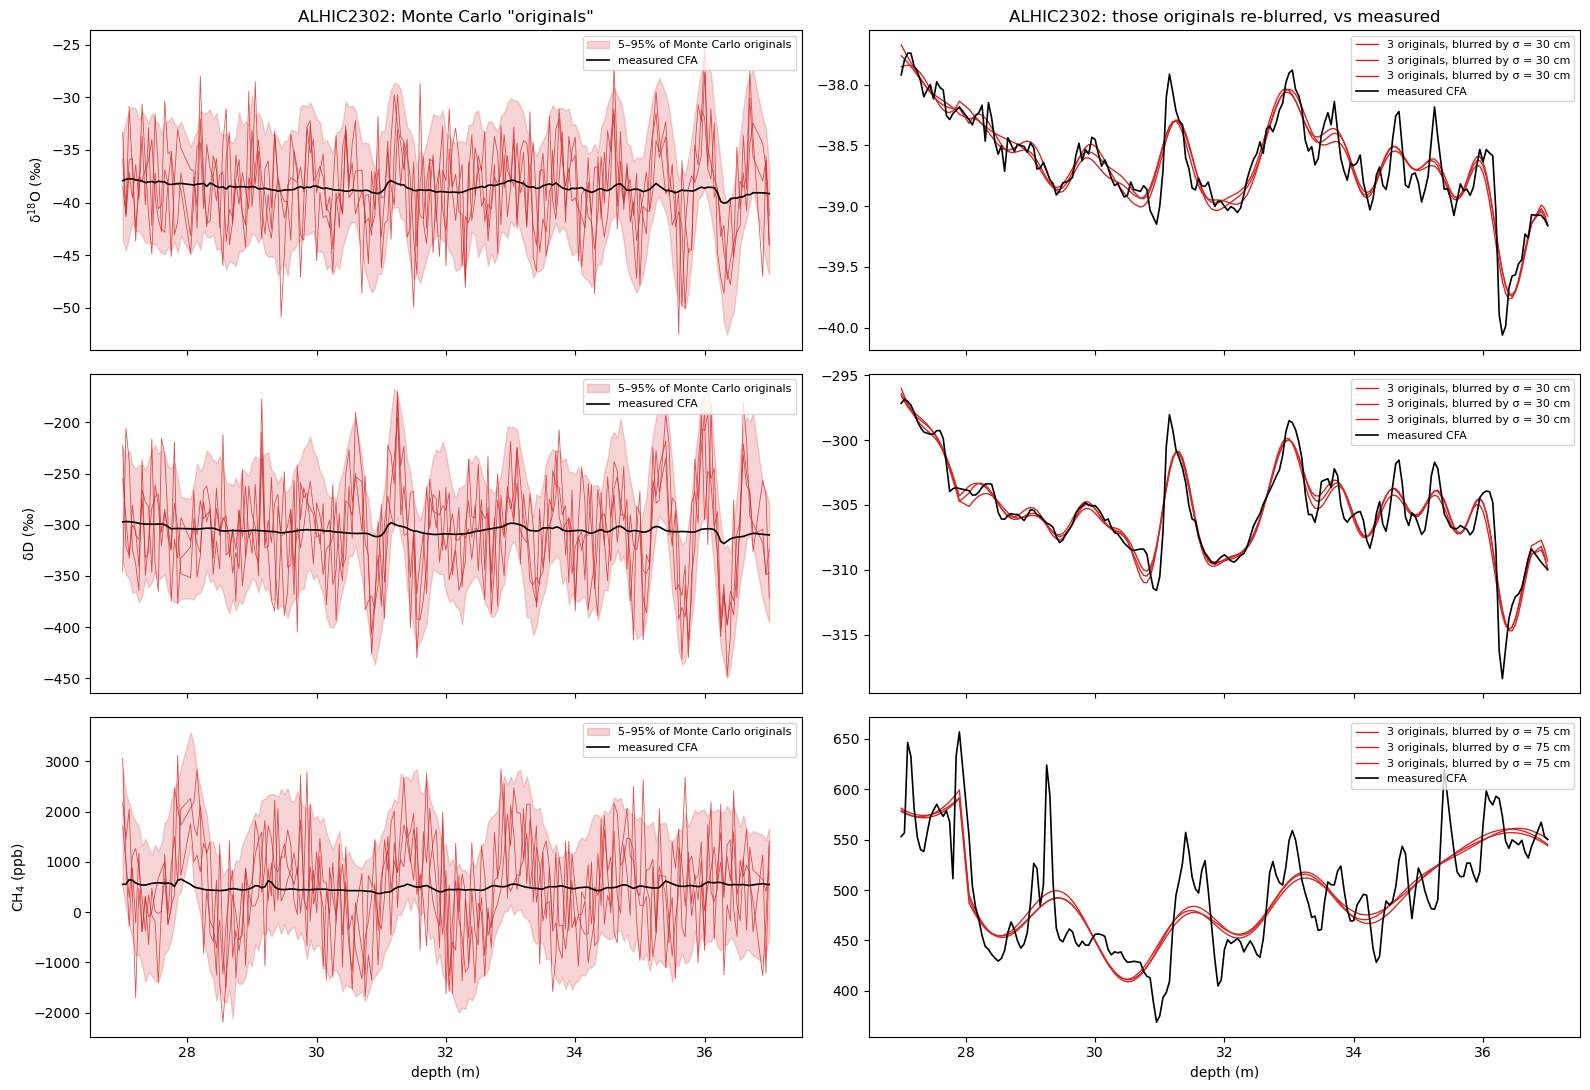

In [39]:
ZOOM = {'ALHIC2201': (12, 22), 'ALHIC2302': (27, 37)}     # depth window to show for each core

results = {}
for name, df in cores.items():
    fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharex=True)
    for i, var in enumerate(['d18O', 'dD', 'CH4']):
        z, y, draws, reblurred, R, noise = mc_originals(df, var, TIERNEY[var])
        results[(name, var)] = (y, draws, reblurred, R, noise)
        w = (z >= ZOOM[name][0]) & (z <= ZOOM[name][1])

        ax = axes[i, 0]
        lo, hi = np.nanpercentile(draws, [5, 95], axis=1)
        ax.fill_between(z[w], lo[w], hi[w], color='C3', alpha=0.2, label='5–95% of Monte Carlo originals')
        ax.plot(z[w], draws[w, :3], color='C3', lw=0.6, alpha=0.8)
        ax.plot(z[w], y[w], 'k', lw=1.2, label='measured CFA')
        ax.set_ylabel(LABELS[var]); ax.legend(fontsize=8, loc='upper right')

        ax = axes[i, 1]
        ax.plot(z[w], reblurred[w, :3], color='C3', lw=1, label=f'3 originals, blurred by σ = {TIERNEY[var]} cm')
        ax.plot(z[w], y[w], 'k', lw=1.2, label='measured CFA')
        ax.legend(fontsize=8, loc='upper right')
    axes[0, 0].set_title(f'{name}: Monte Carlo "originals"')
    axes[0, 1].set_title(f'{name}: those originals re-blurred, vs measured')
    axes[-1, 0].set_xlabel('depth (m)'); axes[-1, 1].set_xlabel('depth (m)')
    plt.tight_layout(); plt.show()


In [41]:
from scipy.special import erfinv

def sigma_star_cm(df, var):
    # Mixing length at which the minimum original span equals the measured CFA range
    s = df.set_index('depth')[var].dropna()
    neighbours = np.isclose(np.diff(s.index), H)
    jump = np.median(np.sort(np.abs(np.diff(s.values))[neighbours])[-5:])   # median of top-5 jumps
    return 100 * H / (2 * np.sqrt(2) * erfinv(jump / np.ptp(s.values)))

SIGMA_STAR = {(name, var): sigma_star_cm(df, var)
              for name, df in cores.items() for var in ['d18O', 'dD', 'CH4']}
for (name, var), s in SIGMA_STAR.items():
    print(f'{name} {var}: σ* = {s:.1f} cm')


ALHIC2201 d18O: σ* = 6.8 cm
ALHIC2201 dD: σ* = 6.1 cm
ALHIC2201 CH4: σ* = 4.8 cm
ALHIC2302 d18O: σ* = 8.2 cm
ALHIC2302 dD: σ* = 6.8 cm
ALHIC2302 CH4: σ* = 10.2 cm


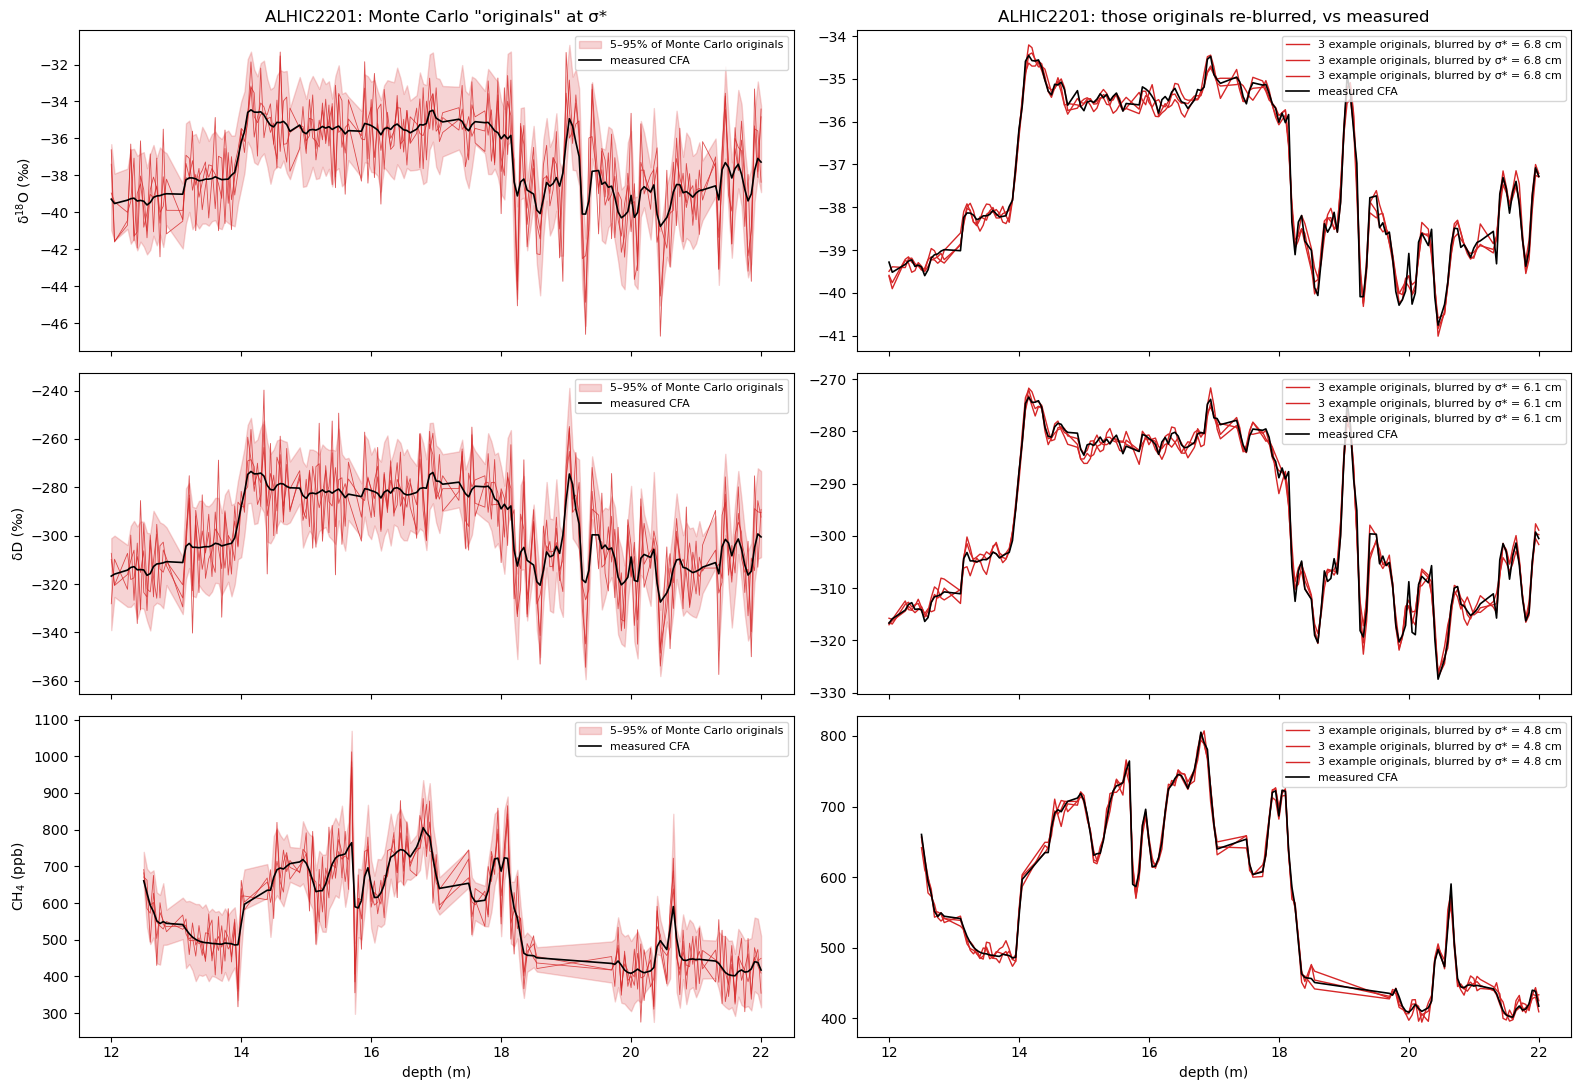

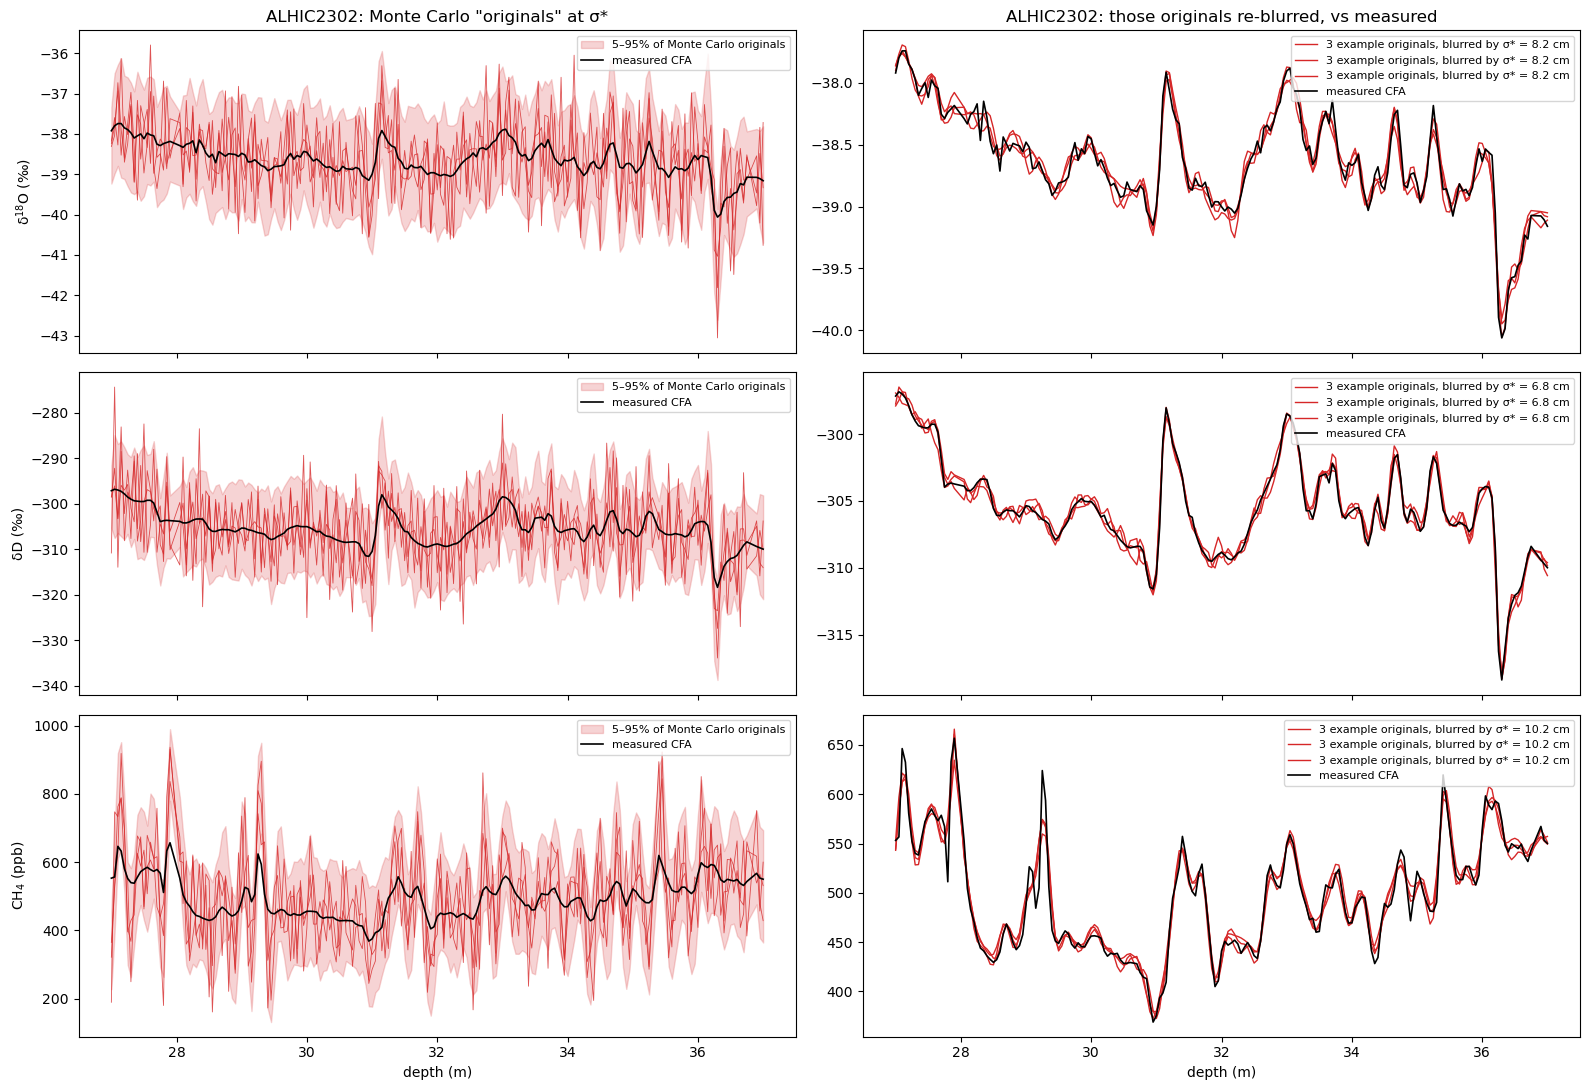

In [42]:
ZOOM = {'ALHIC2201': (12, 22), 'ALHIC2302': (27, 37)}

results_star = {}
for name, df in cores.items():
    fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharex=True)
    for i, var in enumerate(['d18O', 'dD', 'CH4']):
        sigma_cm = SIGMA_STAR[(name, var)]
        z, y, draws, reblurred, R, noise = mc_originals(df, var, sigma_cm)
        results_star[(name, var)] = (y, draws, reblurred, R, noise, sigma_cm)
        w = (z >= ZOOM[name][0]) & (z <= ZOOM[name][1])

        ax = axes[i, 0]
        lo, hi = np.nanpercentile(draws, [5, 95], axis=1)
        ax.fill_between(z[w], lo[w], hi[w], color='C3', alpha=0.2, label='5–95% of Monte Carlo originals')
        ax.plot(z[w], draws[w, :3], color='C3', lw=0.6, alpha=0.8)
        ax.plot(z[w], y[w], 'k', lw=1.2, label='measured CFA')
        ax.set_ylabel(LABELS[var]); ax.legend(fontsize=8, loc='upper right')

        ax = axes[i, 1]
        ax.plot(z[w], reblurred[w, :3], color='C3', lw=1,
                label=f'3 example originals, blurred by σ* = {sigma_cm:.1f} cm')
        ax.plot(z[w], y[w], 'k', lw=1.2, label='measured CFA')
        ax.legend(fontsize=8, loc='upper right')
    axes[0, 0].set_title(f'{name}: Monte Carlo "originals" at σ*')
    axes[0, 1].set_title(f'{name}: those originals re-blurred, vs measured')
    axes[-1, 0].set_xlabel('depth (m)'); axes[-1, 1].set_xlabel('depth (m)')
    plt.tight_layout(); plt.show()


In [43]:
rows = []
for (name, var), (y, draws, reblurred, R, noise, sigma_cm) in results_star.items():
    miss = np.sqrt(np.nanmean((reblurred - y[:, None]) ** 2, axis=0)) / noise
    rows.append({'core': name, 'proxy': var, 'σ* (cm)': sigma_cm,
                 'required span R': R, 'measured range': np.ptp(y),
                 'typical draw range': np.median(np.nanmax(draws, 0) - np.nanmin(draws, 0)),
                 'residual RMS / noise (median)': np.median(miss),
                 'draws within 1.5× noise (%)': 100 * np.mean(miss <= 1.5)})
pd.DataFrame(rows).round(2)


,core,proxy,σ* (cm),required span R,measured range,typical draw range,residual RMS / noise (median),draws within 1.5× noise (%)
0,ALHIC2201,d18O,6.76,8.74,8.74,16.82,1.04,100.0
1,ALHIC2201,dD,6.13,64.68,64.68,122.91,0.99,100.0
2,ALHIC2201,CH4,4.79,455.05,455.05,981.64,0.95,100.0
3,ALHIC2302,d18O,8.21,4.39,4.39,8.52,0.98,100.0
4,ALHIC2302,dD,6.83,37.94,37.94,70.40,0.98,100.0
5,ALHIC2302,CH4,10.22,463.67,463.67,885.67,1.04,100.0
